<a href="https://colab.research.google.com/github/ankit-rathi/quantvesting_v3/blob/main/notebooks/06_QUANTVESTING_SIP_MULTI_STRATEGY_BACKTEST_RISK_CONSTRAINED_INTEGER_SHARES_APPLE_TO_APPLE_RECONCILED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantvesting — Multi-Strategy SIP Backtest (Risk-Constrained, Integer Shares)

## 60-month, ₹2.5 lakh/month comparison across multiple allocation strategies

This notebook is designed for an **apple-to-apple comparison** of the primary equity strategies under the same portfolio implementation rules used in the latest ATH Drawdown + Recovery journey.

### Common equity-portfolio constraints

Every primary stock strategy receives the same ₹2.5 lakh on the first available trading day of every month over the same 60-month window.

For primary equity strategies:

- **15-stock hard holding limit**;
- **TOP_N-stock candidate pool** for each monthly screen;
- **7% maximum position size for new purchases/additions**;
- **20% maximum sector exposure for new purchases**;
- sector exposure may exceed 20% later because of price appreciation; there is no forced sector rebalance;
- **integer shares only** — no fractional shares;
- **12% position review threshold**;
- **15% hard concentration threshold**;
- positions above 15% are partially trimmed at the next monthly execution date toward **12%**, using whole shares;
- no routine selling/rebalancing for normal positions;
- transaction cost = 10 bps;
- slippage = 5 bps;
- only prior-EOD information is used for monthly decisions;
- uninvested cash is carried forward;
- X-LC is preferred over H-LC when otherwise comparable.

The Nifty 50 remains an **index benchmark**. Individual-stock and sector constraints do not apply to the index instrument.

### Strategies tested

1. **Universe Equal-Weight Top-N** — equal target across the 15 highest-priority universe candidates available at the prior EOD, subject to the common constraints.
2. **ATH Drawdown Top-N** — select the TOP_N stocks with the largest current drawdown from running ATH; X-LC is preferred, then larger ATH drawdown.
3. **200-DMA Drawdown Top-N** — select the TOP_N stocks with the largest positive distance below 200-DMA.
4. **ATH + 200-DMA Composite Top-N** — combine cross-sectional ATH drawdown and 200-DMA discount ranks.
5. **ATH Drawdown + Recovery Top-N** — require at least 20% ATH gap and price at/above 200-DMA, then rank by largest ATH gap; X-LC is used only as the tie-break, followed by symbol.
6. **Momentum Top-N** — select the 15 strongest 12-month performers excluding the most recent month.
7. **Risk-Constrained Original Quantvesting** — original conviction/ATH-gap entry logic plus the same common integer/position/sector/risk controls; its frozen-ATH exit rule is retained as an additional strategy-specific exit.
8. **Nifty 50 SIP** — index reference; stock-level caps are not applicable.

### Important interpretation

The common risk controls are deliberately applied **outside** the ranking logic. This means the experiment compares signal/selection rules while holding portfolio implementation assumptions as constant as practical.

The notebook does not use future monthly returns to decide where the SIP goes. A monthly decision uses the prior available EOD and executes at the current month's first trading-day open.

No single historical metric is treated as a universal "winner". The regime, drawdown, deployment, concentration and cash diagnostics should be read alongside XIRR and ending corpus.


In [1]:
# 1. Setup + USER CONFIGURATION
import sys, subprocess, importlib.util, warnings, math, hashlib
from pathlib import Path

if importlib.util.find_spec("yfinance") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# ============================================================
# USER CONFIGURATION — edit this cell only for normal runs
# ============================================================

SIGNAL_FILE = Path("sample_data/signals.csv")

# Journey
START_DATE = "2014-10-01"
END_DATE = "2026-09-30"
EXPECTED_MONTHS = 60          # Set to None to skip this check

# Capital
INITIAL_LUMP_SUM = 10_000_000  # ₹1 crore
MONTHLY_SIP = 100_000           # ₹1 lakh
SIP_IN_FIRST_MONTH = False

# Strategy
ATH_DRAWDOWN_MIN = 0.20        # At least 20% below running ATH
DMA_WINDOW = 200
TOP_N = 20

# Position risk
MAX_HOLDINGS = 15
MAX_POSITION_PCT = 0.07         # Maximum position size created by a new purchase/addition
POSITION_REVIEW_PCT = 0.12      # Review zone
POSITION_HARD_PCT = 0.15         # Hard concentration threshold
POSITION_TRIM_TARGET_PCT = 0.12  # Target after a hard-limit trim

# Sector risk
MAX_SECTOR_PCT = 0.20            # Restricts new purchases; appreciation may exceed it later

# Execution assumptions
TRANSACTION_COST_BPS = 10
SLIPPAGE_BPS = 5

# Historical data
HISTORY_PERIOD = "max"

# If False, an existing holding cannot receive another BUY while it is already held.
ALLOW_REPEAT_BUYS = True

# Current-screen diagnostic date. None = latest available price date.
AS_OF_DATE = None

# Strategy-specific aliases derived from the common ATH threshold.
ENTRY_ATH_GAP = ATH_DRAWDOWN_MIN
RECOVERY_ATH_MIN_GAP = ATH_DRAWDOWN_MIN
MOM_LONG = 252
MOM_SKIP = 21

DATA_DIR = SIGNAL_FILE.parent

print("✓ Environment ready")
print(f"✓ Journey: {START_DATE} → {END_DATE} | expected months: {EXPECTED_MONTHS}")
print(f"✓ Initial lump sum: ₹{INITIAL_LUMP_SUM:,.0f} | monthly SIP: ₹{MONTHLY_SIP:,.0f} | first-month SIP: {SIP_IN_FIRST_MONTH}")
print(f"✓ Candidate pool: TOP_N={TOP_N} | max holdings: {MAX_HOLDINGS}")
print(f"✓ Common equity rules: {MAX_POSITION_PCT:.0%} position | {MAX_SECTOR_PCT:.0%} sector | {POSITION_HARD_PCT:.0%} hard | trim to {POSITION_TRIM_TARGET_PCT:.0%}")
print(f"✓ Execution: {TRANSACTION_COST_BPS} bps cost | {SLIPPAGE_BPS} bps slippage | integer shares only")


✓ Environment ready
✓ Journey: 2014-10-01 → 2026-09-30 | expected months: 60
✓ Initial lump sum: ₹10,000,000 | monthly SIP: ₹100,000 | first-month SIP: False
✓ Candidate pool: TOP_N=20 | max holdings: 15
✓ Common equity rules: 7% position | 20% sector | 15% hard | trim to 12%
✓ Execution: 10 bps cost | 5 bps slippage | integer shares only


In [2]:
# Configuration validation
if pd.Timestamp(END_DATE) < pd.Timestamp(START_DATE):
    raise ValueError("END_DATE must be on or after START_DATE.")
if INITIAL_LUMP_SUM < 0 or MONTHLY_SIP < 0:
    raise ValueError("INITIAL_LUMP_SUM and MONTHLY_SIP must be non-negative.")
if EXPECTED_MONTHS is not None and EXPECTED_MONTHS <= 0:
    raise ValueError("EXPECTED_MONTHS must be positive or None.")
if not (0 < ATH_DRAWDOWN_MIN < 1):
    raise ValueError("ATH_DRAWDOWN_MIN must be between 0 and 1.")
if DMA_WINDOW <= 0 or TOP_N <= 0 or MAX_HOLDINGS <= 0:
    raise ValueError("DMA_WINDOW, TOP_N and MAX_HOLDINGS must be positive.")
if MAX_HOLDINGS > TOP_N:
    print("ℹ MAX_HOLDINGS is below TOP_N: the screen can consider more candidates than can be held simultaneously.")
if not (0 < MAX_POSITION_PCT <= 1):
    raise ValueError("MAX_POSITION_PCT must be between 0 and 1.")
if not (0 < POSITION_REVIEW_PCT <= 1):
    raise ValueError("POSITION_REVIEW_PCT must be between 0 and 1.")
if not (0 < POSITION_TRIM_TARGET_PCT <= POSITION_HARD_PCT <= 1):
    raise ValueError("Require trim target <= hard threshold <= 100%.")
if not (0 < MAX_SECTOR_PCT <= 1):
    raise ValueError("MAX_SECTOR_PCT must be between 0 and 1.")
if TRANSACTION_COST_BPS < 0 or SLIPPAGE_BPS < 0:
    raise ValueError("Transaction cost and slippage cannot be negative.")
if not SIGNAL_FILE.exists():
    raise FileNotFoundError(f"Signal file not found: {SIGNAL_FILE.resolve()}")
print("✓ Configuration validated")


✓ Configuration validated


In [3]:
# 2. Load and validate the same signal universe used by the latest notebook
if not SIGNAL_FILE.exists():
    raise FileNotFoundError(f"Missing {SIGNAL_FILE}. Place the same signals.csv beside this notebook.")

signals_config = pd.read_csv(SIGNAL_FILE)
signals_config.columns = [str(c).strip().lower() for c in signals_config.columns]

required = {"symbol", "conviction", "category"}
missing = required - set(signals_config.columns)
if missing:
    raise ValueError(f"signals.csv is missing columns required for the common portfolio constraints: {sorted(missing)}")

signals_config["symbol"] = signals_config["symbol"].astype(str).str.strip().str.upper()
signals_config["conviction"] = signals_config["conviction"].astype(str).str.strip().str.upper()
signals_config["category"] = signals_config["category"].astype(str).str.strip().replace({"": "Unknown"})

allowed = {"X-LC", "H-LC"}
bad = sorted(set(signals_config["conviction"]) - allowed)
if bad:
    raise ValueError(f"Unsupported conviction values: {bad}. Use X-LC or H-LC.")

if signals_config["symbol"].duplicated().any():
    dupes = signals_config.loc[signals_config["symbol"].duplicated(), "symbol"].tolist()
    raise ValueError(f"Duplicate symbols in signals.csv: {dupes}")

signals_config = signals_config[signals_config["symbol"] != "LTIM"].reset_index(drop=True)
if len(signals_config) < MAX_HOLDINGS:
    raise ValueError(f"Universe contains only {len(signals_config)} securities after exclusions; need at least {MAX_HOLDINGS}.")

YF_TICKERS = {f"{s}.NS": s for s in signals_config["symbol"]}
CATEGORY_MAP = dict(zip(signals_config["symbol"], signals_config["category"]))

print(f"✓ Signal universe: {len(signals_config)} securities")
print(f"✓ Categories available: {signals_config['category'].nunique()}")
display(signals_config.style.hide(axis="index"))


✓ Signal universe: 54 securities
✓ Categories available: 22


symbol,conviction,category
TMPV,X-LC,AUTO
TCS,X-LC,IT
ITC,X-LC,FMCG
INFY,X-LC,IT
JIOFIN,X-LC,FINANCE
VBL,X-LC,FMCG
BAJAJFINSV,X-LC,FINANCE
LTM,H-LC,IT
DLF,H-LC,REALTY
HDFCLIFE,X-LC,INSURANCE


## 2. Data and contribution schedule

The multi-strategy comparison uses the same journey configuration for every equity strategy: initial lump sum, monthly SIP timing, candidate pool, position limits, sector limits, execution costs, and historical-data settings.

Only the **stock-selection rule** changes between strategies. The portfolio implementation and risk controls are held constant for an apple-to-apple comparison.


In [4]:
# 3. Download daily market data

# HISTORY_PERIOD is the user-facing data-history control. The backtest itself is still
# bounded by START_DATE/END_DATE below.
market_download_end = (pd.Timestamp(END_DATE) + pd.Timedelta(days=2)).strftime("%Y-%m-%d")

def yf_download(tickers, start=None, end=None, period=None):
    kwargs = dict(tickers=tickers, interval="1d", auto_adjust=False, actions=False, progress=False, repair=True, group_by="column")
    if period is not None:
        kwargs["period"] = period
    else:
        kwargs.update(start=start, end=end)
    return yf.download(**kwargs)

raw = yf_download(list(YF_TICKERS.keys()), period=HISTORY_PERIOD)

rows=[]
if isinstance(raw.columns, pd.MultiIndex):
    fields = set(raw.columns.get_level_values(0))
    for field in ["Open","High","Low","Close"]:
        if field not in fields: continue
        block = raw[field]
        if isinstance(block, pd.Series): block = block.to_frame()
        for ticker in block.columns:
            symbol = YF_TICKERS.get(str(ticker), str(ticker).replace(".NS", ""))
            s = pd.to_numeric(block[ticker], errors="coerce")
            for d,v in s.dropna().items():
                rows.append((pd.Timestamp(d).tz_localize(None), symbol, field, float(v)))
else:
    ticker = list(YF_TICKERS.keys())[0]
    symbol = YF_TICKERS[ticker]
    for field in ["Open","High","Low","Close"]:
        if field in raw.columns:
            s = pd.to_numeric(raw[field], errors="coerce")
            for d,v in s.dropna().items():
                rows.append((pd.Timestamp(d).tz_localize(None), symbol, field, float(v)))

long = pd.DataFrame(rows, columns=["date","symbol","field","value"])
if long.empty:
    raise RuntimeError("No market data was downloaded. Check internet access and the symbols in signals.csv.")

prices = long.pivot_table(index=["date","symbol"], columns="field", values="value", aggfunc="last").reset_index()
for c in ["Open","High","Low","Close"]:
    if c not in prices.columns:
        raise RuntimeError(f"Downloaded data is missing {c}.")

prices = prices.sort_values(["symbol","date"]).reset_index(drop=True)
prices = prices[prices["date"] <= pd.Timestamp(END_DATE)].copy()

quality = prices.groupby("symbol").agg(first_date=("date","min"), last_date=("date","max"), rows=("date","size"))
print(f"✓ Downloaded {len(prices):,} daily rows across {prices['symbol'].nunique()} securities")
print(f"✓ Data window: {prices['date'].min():%d %b %Y} → {prices['date'].max():%d %b %Y}")
display(quality.sort_values("rows").head(15).style.format({"first_date":"{:%d %b %Y}","last_date":"{:%d %b %Y}","rows":"{:,.0f}"}))


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PIDILITIND.NS']: IntCastingNaNError('Cannot convert non-finite values (NA or inf) to integer')


✓ Downloaded 295,513 daily rows across 53 securities
✓ Data window: 02 Jan 1991 → 18 Sep 2026


,first_date,last_date,rows
symbol,,,
ENRIN,19 Jun 2025,18 Sep 2026,315
HYUNDAI,22 Oct 2024,18 Sep 2026,478
JIOFIN,21 Aug 2023,18 Sep 2026,765
LICI,17 May 2022,18 Sep 2026,"1,079"
POLYCAB,16 Apr 2019,18 Sep 2026,"1,840"
HDFCLIFE,17 Nov 2017,18 Sep 2026,"2,187"
SBILIFE,03 Oct 2017,18 Sep 2026,"2,219"
DMART,21 Mar 2017,18 Sep 2026,"2,352"
BSE,03 Feb 2017,18 Sep 2026,"2,382"


In [5]:
# 4. Build ex-ante signals and the common monthly contribution calendar
prices["conviction"] = prices["symbol"].map(dict(zip(signals_config["symbol"], signals_config["conviction"])))
prices["conviction_rank"] = prices["conviction"].map({"X-LC": 1, "H-LC": 2})
prices["category"] = prices["symbol"].map(CATEGORY_MAP)

prices["running_ath"] = prices.groupby("symbol")["Close"].cummax()
prices["ath_gap"] = (prices["running_ath"] - prices["Close"]) / prices["Close"]
prices["drawdown_from_ath"] = prices["Close"] / prices["running_ath"] - 1
prices["dma200"] = prices.groupby("symbol")["Close"].transform(lambda s: s.rolling(DMA_WINDOW, min_periods=DMA_WINDOW).mean())
prices["dma_gap"] = (prices["dma200"] - prices["Close"]) / prices["Close"]
prices["above_dma200"] = prices["Close"] >= prices["dma200"]
prices["mom_12m_ex1m"] = prices.groupby("symbol")["Close"].transform(lambda s: s.shift(MOM_SKIP) / s.shift(MOM_LONG) - 1)
prices["next_date"] = prices.groupby("symbol")["date"].shift(-1)
prices["next_open"] = prices.groupby("symbol")["Open"].shift(-1)

window = prices[(prices["date"] >= pd.Timestamp(START_DATE)) & (prices["date"] <= pd.Timestamp(END_DATE))]
market_days = pd.DatetimeIndex(sorted(window["date"].unique()))
if market_days.empty:
    raise ValueError("No trading days found inside START_DATE/END_DATE.")

month_first = pd.Series(market_days, index=market_days).groupby(market_days.to_period("M")).first()
sip_dates_all = pd.DatetimeIndex(month_first.values)
first_month = sip_dates_all[0].to_period("M")
sip_dates = pd.DatetimeIndex([d for d in sip_dates_all if SIP_IN_FIRST_MONTH or d.to_period("M") != first_month])
INITIAL_CONTRIBUTION_DATE = pd.Timestamp(sip_dates_all[0])

if EXPECTED_MONTHS is not None and len(sip_dates_all) != EXPECTED_MONTHS:
    print(f"⚠ Expected {EXPECTED_MONTHS} journey months but found {len(sip_dates_all)}. Check START_DATE/END_DATE.")

print(f"✓ Journey months: {len(sip_dates_all)}")
print(f"✓ SIP contribution dates: {len(sip_dates)}")
print(f"✓ Initial lump-sum date: {INITIAL_CONTRIBUTION_DATE:%d %b %Y}")
print(f"✓ Planned external contributions: ₹{INITIAL_LUMP_SUM + MONTHLY_SIP*len(sip_dates):,.0f}")
display(pd.DataFrame({"Contribution Date": sip_dates.strftime("%d %b %Y"), "Monthly SIP": [f"₹{MONTHLY_SIP:,.0f}"] * len(sip_dates)}).head(12).style.hide(axis="index"))


⚠ Expected 60 journey months but found 144. Check START_DATE/END_DATE.
✓ Journey months: 144
✓ SIP contribution dates: 143
✓ Initial lump-sum date: 01 Oct 2014
✓ Planned external contributions: ₹24,300,000


Contribution Date,Monthly SIP
03 Nov 2014,"₹100,000"
01 Dec 2014,"₹100,000"
01 Jan 2015,"₹100,000"
02 Feb 2015,"₹100,000"
02 Mar 2015,"₹100,000"
01 Apr 2015,"₹100,000"
04 May 2015,"₹100,000"
01 Jun 2015,"₹100,000"
01 Jul 2015,"₹100,000"
03 Aug 2015,"₹100,000"


## 2. Strategy definitions — signal rules vs common portfolio rules

The six primary selection rules differ only in **which stocks are eligible/ranked**. The following portfolio implementation rules are common:

- maximum MAX_HOLDINGS open stock positions;
- monthly candidate pool capped at TOP_N;
- integer shares only;
- 7% position cap on new purchases/additions;
- 20% sector cap on new purchases;
- 12% review threshold;
- >15% hard concentration triggers a next-month partial trim toward 12%;
- no routine sector rebalancing merely because price appreciation pushes a sector above 20%;
- no routine selling for the primary no-sell strategies;
- transaction cost and slippage are identical.

### Signal rules

**A. Universe Equal-Weight Top-N**
Uses the 15 highest-priority universe candidates available at the prior EOD. The monthly SIP is allocated equally across those candidates, subject to the common caps. This is a constrained diversified control.

**B. ATH Drawdown Top-N**
Select the 15 stocks with the largest current drawdown from running ATH. X-LC is preferred, then larger ATH drawdown.

**C. 200-DMA Drawdown Top-N**
Select the 15 stocks with the largest positive distance below 200-DMA.

**D. ATH + 200-DMA Composite Top-N**
Combine cross-sectional percentile ranks of ATH drawdown and 200-DMA discount.

**E. ATH Drawdown + Recovery Top-N**
Require at least the configured ATH gap and price at/above 200-DMA, then rank by largest ATH gap. X-LC is the tie-break after drawdown, followed by symbol.

**F. Momentum Top-N**
Select the 15 strongest 12-month performers excluding the most recent month.

**Risk-Constrained Original Quantvesting**
Retains the original X-LC/H-LC + ATH-gap entry process and frozen entry-ATH exit, but now uses the same integer-share, 15-holding, 7% position, 20% sector and concentration-risk controls.

**Nifty 50**
Index benchmark only. Stock-level restrictions are not applicable to the index.


In [6]:
BENCHMARK_TICKER = "^NSEI"
nifty_raw = yf_download([BENCHMARK_TICKER], START_DATE, market_download_end)

def extract_single_col(downloaded, field):
    if downloaded is None or downloaded.empty: return pd.Series(dtype=float)
    if isinstance(downloaded.columns, pd.MultiIndex):
        if field not in downloaded.columns.get_level_values(0): return pd.Series(dtype=float)
        s = downloaded[field]
        if isinstance(s, pd.DataFrame): s = s.iloc[:,0]
    else:
        if field not in downloaded.columns: return pd.Series(dtype=float)
        s = downloaded[field]
    s = pd.to_numeric(s, errors="coerce").dropna()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    return s

nifty_open = extract_single_col(nifty_raw, "Open")
nifty_close = extract_single_col(nifty_raw, "Close")
if nifty_open.empty or nifty_close.empty:
    raise RuntimeError("Could not retrieve Nifty 50 Open/Close data.")

nifty = pd.DataFrame({"close":nifty_close}).sort_index()
nifty["dma200"] = nifty["close"].rolling(200, min_periods=200).mean()
nifty["peak"] = nifty["close"].cummax()
nifty["drawdown"] = nifty["close"] / nifty["peak"] - 1
nifty["ret_6m"] = nifty["close"].pct_change(126)

# A simple diagnostic regime label — deliberately a descriptive classification, not a forecast.
def regime(row):
    dd = row["drawdown"]
    r6 = row["ret_6m"]
    if pd.isna(r6) or pd.isna(row["dma200"]): return "Insufficient history"
    if dd <= -0.10 and r6 < 0: return "Stress / Bear"
    if dd <= -0.10 and r6 >= 0: return "Recovery"
    if dd > -0.03 and r6 > 0 and row["close"] >= row["dma200"]: return "Expansion / Bull"
    return "Transition / Sideways"

nifty["regime"] = nifty.apply(regime, axis=1)
regime_daily = nifty[(nifty.index >= pd.Timestamp(START_DATE)) & (nifty.index <= pd.Timestamp(END_DATE))].copy()
print("✓ Nifty reference and regime diagnostics ready")

✓ Nifty reference and regime diagnostics ready


In [7]:
COST_RATE = TRANSACTION_COST_BPS / 10_000
SLIP_RATE = SLIPPAGE_BPS / 10_000
SIP_SET = set(pd.Timestamp(d) for d in sip_dates)


def market_value(positions, last_close):
    return sum(
        float(pos["shares"]) * float(last_close[s])
        for s, pos in positions.items()
        if s in last_close and np.isfinite(last_close[s])
    )


def sector_values(positions, last_close):
    out = {}
    for symbol, pos in positions.items():
        if symbol not in last_close or not np.isfinite(last_close[symbol]):
            continue
        sector = pos.get("category", CATEGORY_MAP.get(symbol, "Unknown"))
        out[sector] = out.get(sector, 0.0) + float(pos["shares"]) * float(last_close[symbol])
    return out


def buy_with_common_caps(symbol, execution_day, positions, cash, corpus, last_close, strategy_name, signal_row):
    """Buy whole shares while enforcing cash, 7% position, 20% sector and MAX_HOLDINGS holding limits."""
    if symbol not in execution_day.index or cash <= 0 or corpus <= 0:
        return positions, cash, None

    already_held = symbol in positions
    if not already_held and len(positions) >= MAX_HOLDINGS:
        return positions, cash, None
    if already_held and not ALLOW_REPEAT_BUYS:
        return positions, cash, None

    open_px = float(execution_day.loc[symbol, "Open"])
    if not np.isfinite(open_px) or open_px <= 0:
        return positions, cash, None

    entry_px = open_px * (1 + SLIP_RATE)
    all_in = entry_px * (1 + COST_RATE)

    # Size against execution-time marks, not stale prior-close marks.
    current_value = float(positions.get(symbol, {}).get("shares", 0)) * entry_px

    current_sector_value = 0.0
    sector = CATEGORY_MAP.get(symbol, "Unknown")
    for held_symbol, held_pos in positions.items():
        held_sector = held_pos.get("category", CATEGORY_MAP.get(held_symbol, "Unknown"))
        if held_sector != sector:
            continue
        if held_symbol in execution_day.index:
            held_px = float(execution_day.loc[held_symbol, "Open"]) * (1 + SLIP_RATE)
        else:
            held_px = float(last_close.get(held_symbol, 0.0))
        if np.isfinite(held_px) and held_px > 0:
            current_sector_value += int(held_pos["shares"]) * held_px

    position_room = max(0.0, corpus * MAX_POSITION_PCT - current_value)
    sector_room = max(0.0, corpus * MAX_SECTOR_PCT - current_sector_value)

    target = min(cash, position_room, sector_room)
    shares = math.floor(target / all_in)

    if shares <= 0:
        return positions, cash, None

    notional = shares * entry_px
    cost = notional * COST_RATE
    total_out = notional + cost

    if total_out > cash + 1e-9:
        shares = math.floor(cash / all_in)
        notional = shares * entry_px
        cost = notional * COST_RATE
        total_out = notional + cost

    if shares <= 0 or total_out > cash + 1e-9:
        return positions, cash, None

    cash_before = cash
    cash -= total_out

    if already_held:
        positions[symbol]["shares"] += int(shares)
    else:
        positions[symbol] = {
            "shares": int(shares),
            "category": sector,
            "entry_ath": signal_row.get("signal_ath", np.nan),
            "signal_date": signal_row.get("signal_date", pd.NaT),
            "conviction": signal_row.get("conviction", np.nan),
            "rank": signal_row.get("rank", np.nan),
        }

    post_position_value = current_value + notional
    post_sector_value = current_sector_value + notional

    event = {
        "date": None, "event": "SIP BUY", "strategy": strategy_name, "symbol": symbol,
        "price": entry_px, "shares": int(shares), "notional": notional, "cost": cost,
        "cash_before": cash_before, "cash_after": cash,
        "current_value_before": current_value, "position_value_after": post_position_value,
        "position_pct_after": post_position_value / corpus if corpus else np.nan,
        "sector": sector, "sector_value_after": post_sector_value,
        "sector_pct_after": post_sector_value / corpus if corpus else np.nan,
        "corpus_reference": corpus,
    }
    return positions, cash, event


def trim_overweight_positions(execution_day, positions, cash, last_close, strategy_name, date):
    """Trim >15% positions at the next monthly open toward 12%, using whole shares."""
    if not positions:
        return positions, cash, []

    # Match the standalone intended engine: risk trims are assessed at the
    # execution-day OPEN after the new contribution is added.
    execution_values = {}
    for symbol, pos in positions.items():
        if symbol not in execution_day.index:
            continue
        px = float(execution_day.loc[symbol, "Open"])
        if np.isfinite(px) and px > 0:
            execution_values[symbol] = int(pos["shares"]) * px
    corpus = cash + sum(execution_values.values())
    if corpus <= 0:
        return positions, cash, []

    events = []
    for symbol in list(positions.keys()):
        if symbol not in execution_day.index or symbol not in last_close:
            continue

        shares_held = int(positions[symbol]["shares"])
        if shares_held <= 0:
            continue

        current_value = shares_held * float(execution_day.loc[symbol, "Open"])
        current_weight = current_value / corpus
        if current_weight <= POSITION_HARD_PCT:
            continue

        open_px = float(execution_day.loc[symbol, "Open"])
        if not np.isfinite(open_px) or open_px <= 0:
            continue

        sell_px = open_px * (1 - SLIP_RATE)
        target_value = corpus * POSITION_TRIM_TARGET_PCT
        excess_value = max(0.0, current_value - target_value)
        shares_to_sell = min(shares_held, int(math.floor(excess_value / sell_px + 1e-12)))

        if shares_to_sell <= 0:
            continue

        gross = shares_to_sell * sell_px
        cost = gross * COST_RATE
        proceeds = gross - cost
        cash_before = cash
        cash += proceeds
        positions[symbol]["shares"] -= shares_to_sell

        remaining_value = positions[symbol]["shares"] * float(execution_day.loc[symbol, "Open"])
        post_weight = remaining_value / (cash + sum(int(p["shares"]) * float(execution_day.loc[s, "Open"]) for s, p in positions.items() if s in execution_day.index)) if corpus else np.nan

        events.append({
            "date": date, "event": "TRIM", "strategy": strategy_name, "symbol": symbol,
            "price": sell_px, "shares": -int(shares_to_sell), "notional": gross,
            "cost": cost, "cash_before": cash_before, "cash_after": cash,
            "reason": f"Position {current_weight:.2%} > hard {POSITION_HARD_PCT:.0%}; trim toward {POSITION_TRIM_TARGET_PCT:.0%}",
            "position_pct_before": current_weight, "position_pct_after": post_weight,
            "sector": positions[symbol].get("category", CATEGORY_MAP.get(symbol, "Unknown")),
        })

        if positions[symbol]["shares"] == 0:
            del positions[symbol]

    return positions, cash, events


def monthly_candidates(signal_day, strategy_name):
    """Rank candidates using only the prior EOD signal_day information."""
    d = signal_day.copy()
    # Make 'symbol' a regular column if it's the index.
    if d.index.name == 'symbol':
        d = d.reset_index()
    d = d[d["symbol"].isin(signals_config["symbol"])].copy()
    d = d.dropna(subset=["Close"])
    d["conviction_priority"] = d["conviction_rank"].fillna(99)

    if strategy_name == "Universe Equal-Weight Top-N":
        return d.sort_values(["conviction_priority", "symbol"], ascending=[True, True]).head(TOP_N)

    if strategy_name == "ATH Drawdown Top-N":
        pool = d.nlargest(min(TOP_N, len(d)), "ath_gap")
        return pool.sort_values(["conviction_priority", "ath_gap", "symbol"], ascending=[True, False, True])

    if strategy_name == "200-DMA Drawdown Top-N":
        eligible = d[d["dma_gap"] > 0]
        pool = eligible.nlargest(min(TOP_N, len(eligible)), "dma_gap")
        return pool.sort_values(["conviction_priority", "dma_gap", "symbol"], ascending=[True, False, True])

    if strategy_name == "ATH + 200-DMA Composite Top-N":
        q = d[["symbol", "ath_gap", "dma_gap"]].copy()
        q["ath_pct_rank"] = q["ath_gap"].rank(pct=True)
        q["dma_pct_rank"] = q["dma_gap"].rank(pct=True)
        d = d.merge(q[["symbol", "ath_pct_rank", "dma_pct_rank"]], on="symbol", how="left")
        d["composite"] = 0.5 * d["ath_pct_rank"] + 0.5 * d["dma_pct_rank"]
        pool = d.nlargest(min(TOP_N, len(d)), "composite")
        return pool.sort_values(["conviction_priority", "composite", "symbol"], ascending=[True, False, True])

    if strategy_name == "ATH Drawdown + Recovery Top-N":
        pool = d[(d["ath_gap"] >= RECOVERY_ATH_MIN_GAP) & (d["above_dma200"] == True)].copy()
        # Canonical standalone rule: largest ATH drawdown first; X-LC only
        # breaks otherwise-equal candidates, then symbol for determinism.
        return pool.sort_values(
            ["ath_gap", "conviction_priority", "symbol"],
            ascending=[False, True, True]
        ).head(TOP_N)

    if strategy_name == "Momentum Top-N":
        pool = d.dropna(subset=["mom_12m_ex1m"]).nlargest(TOP_N, "mom_12m_ex1m")
        return pool.sort_values(["conviction_priority", "mom_12m_ex1m", "symbol"], ascending=[True, False, True])

    raise ValueError(strategy_name)

In [8]:
PRIMARY_STRATEGIES = [
    "Universe Equal-Weight Top-N",
    "ATH Drawdown Top-N",
    "200-DMA Drawdown Top-N",
    "ATH + 200-DMA Composite Top-N",
    "ATH Drawdown + Recovery Top-N",
    "Momentum Top-N",
]


def run_primary_sip(prices, sip_dates, strategy_name, sip_amount=MONTHLY_SIP):
    """Common monthly SIP engine with identical portfolio constraints across signal strategies."""
    df = prices.sort_values(["date", "symbol"]).copy()
    dates = sorted(df[df["date"] >= pd.Timestamp(START_DATE)]["date"].unique())

    positions, cash = {}, 0.0
    contributed = 0.0
    initial_added = False
    rows, tx, contribs = [], [], []
    last_close = {}

    for date in dates:
        date = pd.Timestamp(date)
        day = df[df["date"] == date].set_index("symbol")

        # Initial lump sum is an external contribution at the journey start.
        if not initial_added and date == INITIAL_CONTRIBUTION_DATE:
            cash += INITIAL_LUMP_SUM
            contributed += INITIAL_LUMP_SUM
            contribs.append({"date": date, "contribution": INITIAL_LUMP_SUM, "cumulative_contributed": contributed, "type": "INITIAL LUMP SUM"})
            initial_added = True

        if date in SIP_SET:
            cash += sip_amount
            contributed += sip_amount
            contribs.append({"date": date, "contribution": sip_amount, "cumulative_contributed": contributed, "type": "MONTHLY SIP"})

            positions, cash, trim_events = trim_overweight_positions(
                day, positions, cash, last_close, strategy_name, date
            )
            tx.extend(trim_events)

            # Match standalone intended sizing: mark existing holdings at the
            # first-day OPEN after contribution and before new purchases.
            execution_invested = 0.0
            for held_symbol, held_pos in positions.items():
                if held_symbol in day.index:
                    px = float(day.loc[held_symbol, "Open"])
                    if np.isfinite(px) and px > 0:
                        execution_invested += int(held_pos["shares"]) * px
            corpus = cash + execution_invested

            prior_dates = [d for d in dates if pd.Timestamp(d) < date]
            signal_date = pd.Timestamp(prior_dates[-1]) if prior_dates else None
            signal_day = df[df["date"] == signal_date].set_index("symbol") if signal_date is not None else pd.DataFrame()

            candidates = monthly_candidates(signal_day, strategy_name) if not signal_day.empty else pd.DataFrame()

            for _, row in candidates.iterrows():
                if cash <= 0:
                    break
                symbol = row["symbol"]

                if strategy_name == "Universe Equal-Weight Top-N":
                    target_cash = min(sip_amount / max(1, len(candidates)), cash)
                else:
                    target_cash = cash

                # For equal-weight, temporarily limit available cash to the equal target.
                cash_for_trade = min(cash, target_cash)
                cash_before_trade = cash
                if cash_for_trade <= 0:
                    continue

                # The shared helper sizes from cash. To preserve the equal-weight
                # target, pass a temporary cash balance and restore any unspent amount.
                if strategy_name == "Universe Equal-Weight Top-N":
                    positions, temp_cash, event = buy_with_common_caps(
                        symbol, day, positions, cash_for_trade, corpus,
                        last_close, strategy_name,
                        {
                            "signal_ath": row.get("running_ath", np.nan),
                            "signal_date": signal_date,
                            "conviction": row.get("conviction", np.nan),
                            "rank": row.get("conviction_rank", np.nan),
                        }
                    )
                    spent = cash_for_trade - temp_cash
                    cash = cash_before_trade - spent
                else:
                    positions, cash, event = buy_with_common_caps(
                        symbol, day, positions, cash, corpus, last_close,
                        strategy_name,
                        {
                            "signal_ath": row.get("running_ath", np.nan),
                            "signal_date": signal_date,
                            "conviction": row.get("conviction", np.nan),
                            "rank": row.get("conviction_rank", np.nan),
                        }
                    )

                if event is None:
                    continue

                event.update({
                    "date": date,
                    "signal_date": signal_date,
                    "conviction": row.get("conviction"),
                    "conviction_rank": row.get("conviction_rank"),
                    "ath_gap": row.get("ath_gap"),
                    "dma_gap": row.get("dma_gap"),
                    "mom_12m_ex1m": row.get("mom_12m_ex1m"),
                })
                tx.append(event)

        for symbol, row in day.iterrows():
            px = float(row["Close"])
            if np.isfinite(px) and px > 0:
                last_close[symbol] = px

        invested = market_value(positions, last_close)
        corpus = cash + invested
        rows.append({
            "date": date, "cash": cash, "invested_value": invested, "portfolio_value": corpus,
            "contributed_capital": contributed, "open_positions": len(positions),
            "cash_pct": cash / corpus if corpus else np.nan,
            "invested_pct": invested / corpus if corpus else np.nan,
        })

    return pd.DataFrame(rows), pd.DataFrame(tx), pd.DataFrame(contribs)


def monthly_candidates(signal_day, strategy_name):
    """Rank candidates using only the prior EOD signal_day information."""
    d = signal_day.copy()
    # Make 'symbol' a regular column if it's the index.
    if d.index.name == 'symbol':
        d = d.reset_index()
    d = d[d["symbol"].isin(signals_config["symbol"])].copy()
    d = d.dropna(subset=["Close"])
    d["conviction_priority"] = d["conviction_rank"].fillna(99)

    if strategy_name == "Universe Equal-Weight Top-N":
        return d.sort_values(["conviction_priority", "symbol"], ascending=[True, True]).head(TOP_N)

    if strategy_name == "ATH Drawdown Top-N":
        pool = d.nlargest(min(TOP_N, len(d)), "ath_gap")
        return pool.sort_values(["conviction_priority", "ath_gap", "symbol"], ascending=[True, False, True])

    if strategy_name == "200-DMA Drawdown Top-N":
        eligible = d[d["dma_gap"] > 0]
        pool = eligible.nlargest(min(TOP_N, len(eligible)), "dma_gap")
        return pool.sort_values(["conviction_priority", "dma_gap", "symbol"], ascending=[True, False, True])

    if strategy_name == "ATH + 200-DMA Composite Top-N":
        q = d[["symbol", "ath_gap", "dma_gap"]].copy()
        q["ath_pct_rank"] = q["ath_gap"].rank(pct=True)
        q["dma_pct_rank"] = q["dma_gap"].rank(pct=True)
        d = d.merge(q[["symbol", "ath_pct_rank", "dma_pct_rank"]], on="symbol", how="left")
        d["composite"] = 0.5 * d["ath_pct_rank"] + 0.5 * d["dma_pct_rank"]
        pool = d.nlargest(min(TOP_N, len(d)), "composite")
        return pool.sort_values(["conviction_priority", "composite", "symbol"], ascending=[True, False, True])

    if strategy_name == "ATH Drawdown + Recovery Top-N":
        pool = d[(d["ath_gap"] >= RECOVERY_ATH_MIN_GAP) & (d["above_dma200"] == True)].copy()
        # Canonical standalone rule: largest ATH drawdown first; X-LC only
        # breaks otherwise-equal candidates, then symbol for determinism.
        return pool.sort_values(
            ["ath_gap", "conviction_priority", "symbol"],
            ascending=[False, True, True]
        ).head(TOP_N)

    if strategy_name == "Momentum Top-N":
        pool = d.dropna(subset=["mom_12m_ex1m"]).nlargest(TOP_N, "mom_12m_ex1m")
        return pool.sort_values(["conviction_priority", "mom_12m_ex1m", "symbol"], ascending=[True, False, True])

    raise ValueError(strategy_name)


results = {}
for strategy in PRIMARY_STRATEGIES:
    p, t, c = run_primary_sip(prices, sip_dates, strategy)
    results[strategy] = {"portfolio": p, "trades": t, "contributions": c}
    trims = int((t["event"] == "TRIM").sum()) if not t.empty else 0
    buys = int((t["event"] == "SIP BUY").sum()) if not t.empty else 0
    print(f"✓ {strategy}: {buys:,} buys | {trims:,} trims")

✓ Universe Equal-Weight Top-N: 1,921 buys | 0 trims
✓ ATH Drawdown Top-N: 290 buys | 4 trims
✓ 200-DMA Drawdown Top-N: 227 buys | 2 trims
✓ ATH + 200-DMA Composite Top-N: 301 buys | 4 trims
✓ ATH Drawdown + Recovery Top-N: 162 buys | 4 trims
✓ Momentum Top-N: 157 buys | 4 trims


In [9]:
# 8. Risk-Constrained Original Quantvesting reference
# Retains the original conviction + ATH-gap entry and frozen-ATH exit,
# while using the same integer/15-holding/7% position/20% sector/risk controls.

def run_original_quantvesting_sip(prices, sip_dates, sip_amount=MONTHLY_SIP):
    df = prices.sort_values(["date", "symbol"]).copy()
    dates = sorted(df[df["date"] >= pd.Timestamp(START_DATE)]["date"].unique())

    positions, pending = {}, {}
    cash = 0.0
    contributed = 0.0
    initial_added = False
    last_close = {}
    rows, tx, contribs = [], [], []

    for date in dates:
        date = pd.Timestamp(date)
        day = df[df["date"] == date].set_index("symbol")

        if not initial_added and date == INITIAL_CONTRIBUTION_DATE:
            cash += INITIAL_LUMP_SUM
            contributed += INITIAL_LUMP_SUM
            contribs.append({"date": date, "contribution": INITIAL_LUMP_SUM, "cumulative_contributed": contributed, "type": "INITIAL LUMP SUM"})
            initial_added = True

        if date in SIP_SET:
            cash += sip_amount
            contributed += sip_amount
            contribs.append({"date": date, "contribution": sip_amount, "cumulative_contributed": contributed, "type": "MONTHLY SIP"})

            positions, cash, trim_events = trim_overweight_positions(
                day, positions, cash, last_close,
                "Risk-Constrained Original Quantvesting", date
            )
            tx.extend(trim_events)

        # Execute prior-EOD frozen-ATH signals at the next trading-day open.
        scheduled = sorted(
            pending.pop(date, []),
            key=lambda x: (x["rank"], -x["ath_gap"], x["symbol"])
        )

        invested_now = market_value(positions, last_close)
        corpus = cash + invested_now

        for sig in scheduled:
            symbol = sig["symbol"]
            if symbol not in day.index:
                continue
            if symbol in positions and not ALLOW_REPEAT_BUYS:
                continue
            if cash <= 0:
                break

            positions, cash, event = buy_with_common_caps(
                symbol, day, positions, cash, corpus,
                last_close, "Risk-Constrained Original Quantvesting",
                {
                    "signal_ath": sig["signal_ath"],
                    "signal_date": sig["signal_date"],
                    "conviction": sig["conviction"],
                    "rank": sig["rank"],
                }
            )
            if event is not None:
                event.update({
                    "date": date,
                    "signal_date": sig["signal_date"],
                    "conviction": sig["conviction"],
                    "conviction_rank": sig["rank"],
                    "ath_gap": sig["ath_gap"],
                })
                tx.append(event)

        for symbol, row in day.iterrows():
            px = float(row["Close"])
            if np.isfinite(px) and px > 0:
                last_close[symbol] = px

        # Original frozen-ATH exit remains strategy-specific.
        for symbol in list(positions):
            if symbol not in day.index:
                continue
            pos = positions[symbol]
            high_px = float(day.loc[symbol, "High"])
            if np.isfinite(high_px) and high_px >= pos.get("entry_ath", np.inf):
                exit_px = float(pos["entry_ath"]) * (1 - SLIP_RATE)
                shares = int(pos["shares"])
                gross = shares * exit_px
                cost = gross * COST_RATE
                cash_before = cash
                cash += gross - cost
                tx.append({
                    "date": date, "event": "EXIT", "strategy": "Risk-Constrained Original Quantvesting",
                    "symbol": symbol, "price": exit_px, "shares": -shares,
                    "notional": gross, "cost": cost, "cash_before": cash_before, "cash_after": cash,
                    "reason": "Frozen entry ATH reached",
                    "sector": pos.get("category", CATEGORY_MAP.get(symbol, "Unknown"))
                })
                del positions[symbol]

        # Today's EOD signal schedules next-day entry.
        slots = MAX_HOLDINGS - len(positions)
        if slots > 0:
            cand = df[
                (df["date"] == date)
                & (df["conviction"].isin(["X-LC", "H-LC"]))
                & (df["ath_gap"] >= ENTRY_ATH_GAP)
                & (~df["symbol"].isin(positions.keys()))
            ].copy()
            cand = cand.sort_values(
                ["conviction_rank", "ath_gap", "symbol"], ascending=[True, False, True]
            ).head(TOP_N)

            for _, r in cand.iterrows():
                if pd.isna(r["next_date"]):
                    continue
                pending.setdefault(pd.Timestamp(r["next_date"]), []).append({
                    "symbol": r["symbol"],
                    "signal_date": date,
                    "signal_ath": float(r["running_ath"]),
                    "conviction": r["conviction"],
                    "rank": int(r["conviction_rank"]),
                    "ath_gap": float(r["ath_gap"]),
                })

        invested = market_value(positions, last_close)
        corpus = cash + invested
        rows.append({
            "date": date, "cash": cash, "invested_value": invested,
            "portfolio_value": corpus, "contributed_capital": contributed,
            "open_positions": len(positions),
            "cash_pct": cash / corpus if corpus else np.nan,
            "invested_pct": invested / corpus if corpus else np.nan
        })

    return pd.DataFrame(rows), pd.DataFrame(tx), pd.DataFrame(contribs)


qref_p, qref_t, qref_c = run_original_quantvesting_sip(prices, sip_dates)
results["Risk-Constrained Original Quantvesting"] = {
    "portfolio": qref_p, "trades": qref_t, "contributions": qref_c
}
print(f"✓ Risk-Constrained Original Quantvesting: {len(qref_t):,} trade events")


✓ Risk-Constrained Original Quantvesting: 169 trade events


In [10]:
# 9. Nifty 50 SIP reference

def run_nifty_sip(nifty_open,nifty_close,sip_dates,sip_amount=MONTHLY_SIP):
    idx=nifty_close.index[(nifty_close.index>=pd.Timestamp(START_DATE))&(nifty_close.index<=pd.Timestamp(END_DATE))]
    cash=0.0; units=0.0; contributed=0.0; rows=[]; tx=[]; initial_added=False
    for d in idx:
        d=pd.Timestamp(d)
        if (not initial_added) and d == INITIAL_CONTRIBUTION_DATE:
            cash += INITIAL_LUMP_SUM; contributed += INITIAL_LUMP_SUM; initial_added=True
        if d in SIP_SET and d in nifty_open.index:
            cash+=sip_amount; contributed+=sip_amount
            px=float(nifty_open.loc[d])*(1+SLIP_RATE); all_in=px*(1+COST_RATE)
            add_units=cash/all_in; notional=add_units*px; cost=notional*COST_RATE
            cash-=notional+cost; units+=add_units
            tx.append({"date":d,"event":"SIP BUY","strategy":"Nifty 50","price":px,"units":add_units,"notional":notional,"cost":cost})
        value=cash+units*float(nifty_close.loc[d])
        rows.append({"date":d,"cash":cash,"invested_value":units*float(nifty_close.loc[d]),"portfolio_value":value,"contributed_capital":contributed,"open_positions":1 if units>0 else 0,"cash_pct":cash/value if value else np.nan,"invested_pct":(units*float(nifty_close.loc[d]))/value if value else np.nan})
    return pd.DataFrame(rows),pd.DataFrame(tx)

nifty_p,nifty_t=run_nifty_sip(nifty_open,nifty_close,sip_dates)
results["Nifty 50"]={"portfolio":nifty_p,"trades":nifty_t,"contributions":pd.DataFrame({"date":[INITIAL_CONTRIBUTION_DATE]+list(sip_dates),"contribution":[INITIAL_LUMP_SUM]+[MONTHLY_SIP]*len(sip_dates)})}
print(f"✓ Nifty 50 reference: {len(nifty_t):,} SIP purchases")


✓ Nifty 50 reference: 138 SIP purchases


## 3. Performance measurement

Because the cash contributions are staggered, **XIRR** is the primary return measure rather than CAGR.

The notebook also measures:

- ending corpus and profit over contributed capital;
- maximum drawdown of portfolio corpus;
- average invested and cash percentages;
- final unutilized cash;
- SIP deployment ratio;
- number of holdings;
- concentration in the largest 5/10 holdings;
- annual/calendar-period results;
- performance during automatically classified Nifty regimes;
- monthly contribution-level diagnostics.

No single metric is used to declare a strategy universally superior.


In [11]:
# 10. Metrics and common portfolio calculations

def add_drawdown(p):
    p = p.copy()
    p["peak"] = p["portfolio_value"].cummax()
    p["drawdown"] = p["portfolio_value"] / p["peak"] - 1
    return p

for k, v in results.items():
    results[k]["portfolio"] = add_drawdown(v["portfolio"])


def xirr(cashflows):
    if len(cashflows) < 2:
        return np.nan
    dates = pd.to_datetime(cashflows["date"]).dt.to_pydatetime()
    amounts = np.asarray(cashflows["amount"], dtype=float)
    t0 = dates[0]
    years = np.array([(d - t0).days / 365.25 for d in dates])

    def npv(r):
        if r <= -0.999999:
            return np.inf
        return np.sum(amounts / ((1 + r) ** years))

    lo, hi = -0.9999, 10.0
    flo, fhi = npv(lo), npv(hi)
    if not np.isfinite(flo) or not np.isfinite(fhi) or flo * fhi > 0:
        return np.nan

    for _ in range(250):
        mid = (lo + hi) / 2
        fm = npv(mid)
        if abs(fm) < 1e-8:
            return mid
        if flo * fm <= 0:
            hi, fhi = mid, fm
        else:
            lo, flo = mid, fm
    return (lo + hi) / 2


def strategy_metrics(name, p, t):
    end = float(p["portfolio_value"].iloc[-1])
    contributed = float(p["contributed_capital"].iloc[-1])
    contribution_rows = results[name].get("contributions", pd.DataFrame()).copy()
    cf_rows = []
    if not contribution_rows.empty:
        for _, r in contribution_rows.iterrows():
            cf_rows.append({"date": r["date"], "amount": -float(r["contribution"])})
    cf_rows.append({"date": p["date"].iloc[-1], "amount": end})
    cf = pd.DataFrame(cf_rows)

    buys = t[t["event"].astype(str).str.contains("BUY|ENTRY", regex=True)] if not t.empty else pd.DataFrame()
    trims = t[t["event"].astype(str).str.contains("TRIM", regex=True)] if not t.empty else pd.DataFrame()
    exits = t[t["event"].astype(str).str.contains("EXIT", regex=True)] if not t.empty else pd.DataFrame()

    return {
        "Contributed Capital": contributed,
        "Ending Corpus": end,
        "Profit": end - contributed,
        "XIRR": xirr(cf),
        "Max Drawdown": float(p["drawdown"].min()),
        "Average Invested %": float(p["invested_pct"].mean()),
        "Average Cash %": float(p["cash_pct"].mean()),
        "Final Cash": float(p["cash"].iloc[-1]),
        "Deployment %": (buys["notional"].sum() / contributed * 100) if (not buys.empty and contributed) else np.nan,
        "Final Holdings": int(p["open_positions"].iloc[-1]),
        "Buy Events": int(len(buys)),
        "Trim Events": int(len(trims)),
        "Exit Events": int(len(exits)),
    }


metrics = pd.DataFrame({
    name: strategy_metrics(name, v["portfolio"], v["trades"])
    for name, v in results.items()
}).T

fmt = {
    "Contributed Capital": "₹{:,.0f}", "Ending Corpus": "₹{:,.0f}", "Profit": "₹{:,.0f}",
    "XIRR": "{:.2%}", "Max Drawdown": "{:.2%}", "Average Invested %": "{:.2%}",
    "Average Cash %": "{:.2%}", "Final Cash": "₹{:,.0f}", "Deployment %": "{:.1f}%"
}
display(metrics.style.format(fmt))


,Contributed Capital,Ending Corpus,Profit,XIRR,Max Drawdown,Average Invested %,Average Cash %,Final Cash,Deployment %,Final Holdings,Buy Events,Trim Events,Exit Events
Universe Equal-Weight Top-N,"₹24,300,000","₹40,737,680","₹16,437,680",6.00%,-15.99%,38.28%,61.72%,"₹15,952,364",34.3%,15.000000,1921.000000,0.000000,0.000000
ATH Drawdown Top-N,"₹24,300,000","₹114,712,400","₹90,412,400",17.74%,-39.79%,99.39%,0.61%,₹146,128.1%,15.000000,290.000000,4.000000,0.000000
200-DMA Drawdown Top-N,"₹24,300,000","₹113,990,209","₹89,690,209",17.67%,-41.85%,96.95%,3.05%,₹227,112.6%,15.000000,227.000000,2.000000,0.000000
ATH + 200-DMA Composite Top-N,"₹24,300,000","₹96,138,627","₹71,838,627",15.74%,-37.47%,99.39%,0.61%,₹114,128.2%,15.000000,301.000000,4.000000,0.000000
ATH Drawdown + Recovery Top-N,"₹24,300,000","₹119,227,217","₹94,927,217",18.18%,-39.09%,97.45%,2.55%,₹204,114.1%,15.000000,162.000000,4.000000,0.000000
Momentum Top-N,"₹24,300,000","₹123,241,321","₹98,941,321",18.56%,-39.76%,95.84%,4.16%,₹110,116.2%,15.000000,157.000000,4.000000,0.000000
Risk-Constrained Original Quantvesting,"₹24,300,000","₹83,931,379","₹59,631,379",14.20%,-28.29%,83.59%,16.41%,"₹14,036,105",1057.8%,15.000000,91.000000,2.000000,76.000000
Nifty 50,"₹23,800,000","₹52,872,649","₹29,072,649",8.97%,-37.85%,99.42%,0.58%,₹0,99.9%,1.000000,138.000000,0.000000,0.000000


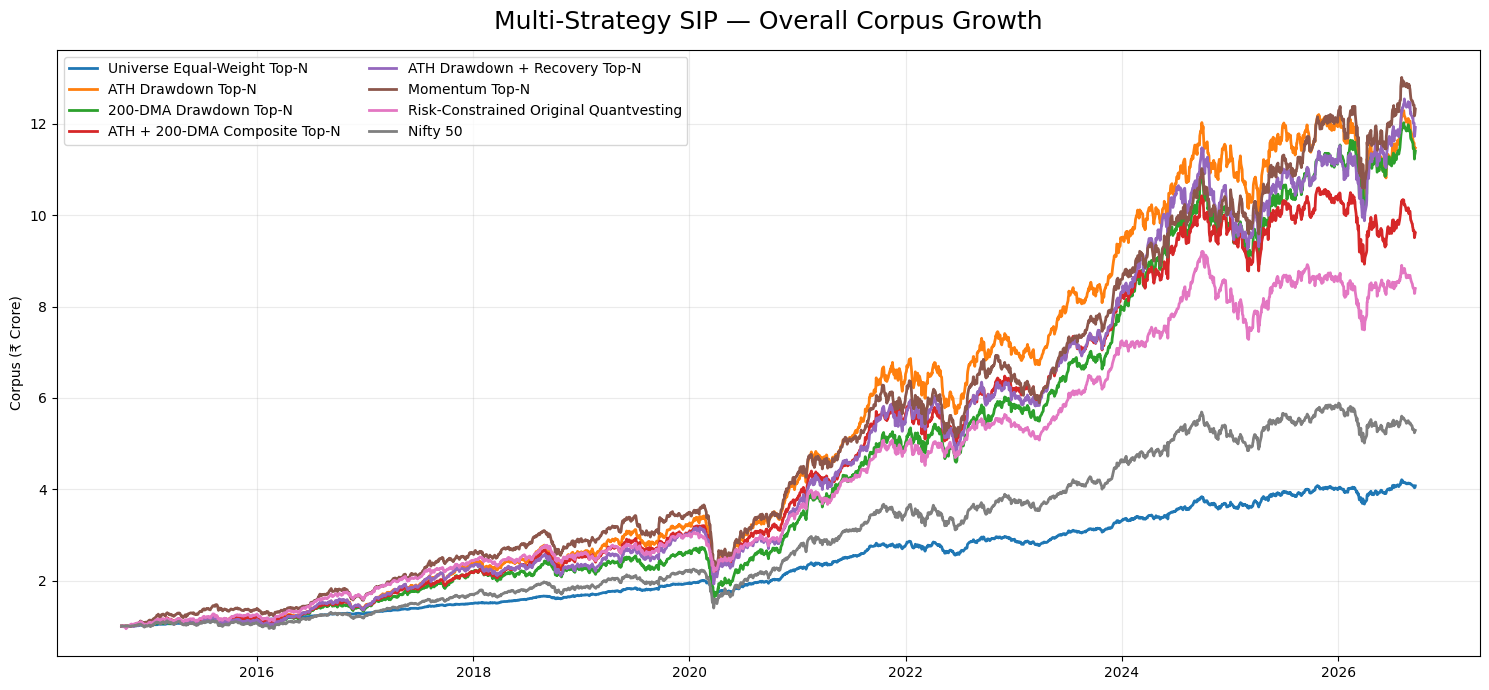

In [12]:
# 11. Overall corpus growth — same SIP contributions for every strategy
paths=pd.concat([v["portfolio"].set_index("date")["portfolio_value"].rename(k) for k,v in results.items()],axis=1).sort_index().ffill()
fig,ax=plt.subplots(figsize=(15,7))
for col in paths.columns: ax.plot(paths.index,paths[col]/1e7,label=col,linewidth=2)
ax.set_title("Multi-Strategy SIP — Overall Corpus Growth",fontsize=18,pad=15)
ax.set_ylabel("Corpus (₹ Crore)"); ax.grid(alpha=.25); ax.legend(ncol=2); plt.tight_layout(); plt.show()


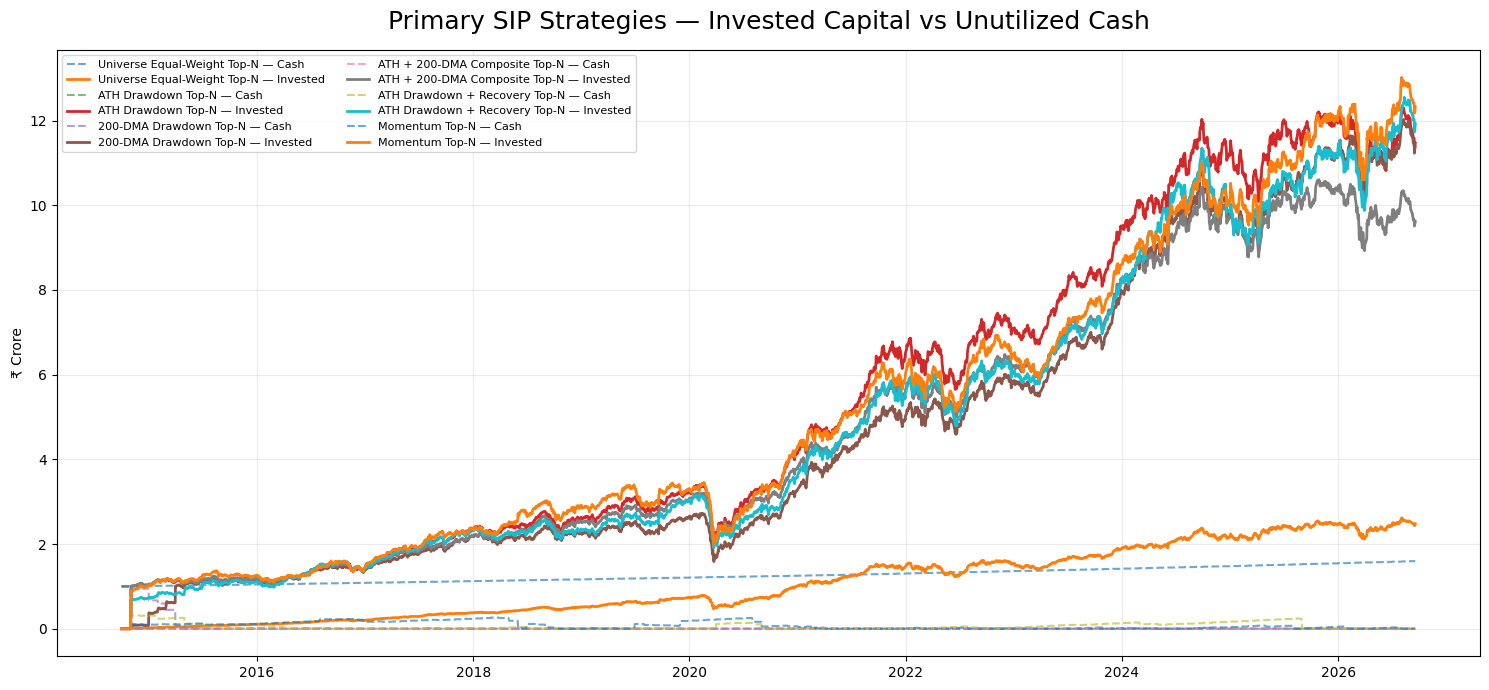

In [13]:
# 12. Invested value vs unutilized cash — primary strategies
fig,ax=plt.subplots(figsize=(15,7))
for name in PRIMARY_STRATEGIES:
    p=results[name]["portfolio"].set_index("date")
    ax.plot(p.index,p["cash"]/1e7,linestyle="--",alpha=.65,label=f"{name} — Cash")
    ax.plot(p.index,p["invested_value"]/1e7,linewidth=2,label=f"{name} — Invested")
ax.set_title("Primary SIP Strategies — Invested Capital vs Unutilized Cash",fontsize=18,pad=15)
ax.set_ylabel("₹ Crore"); ax.grid(alpha=.25); ax.legend(ncol=2,fontsize=8); plt.tight_layout(); plt.show()


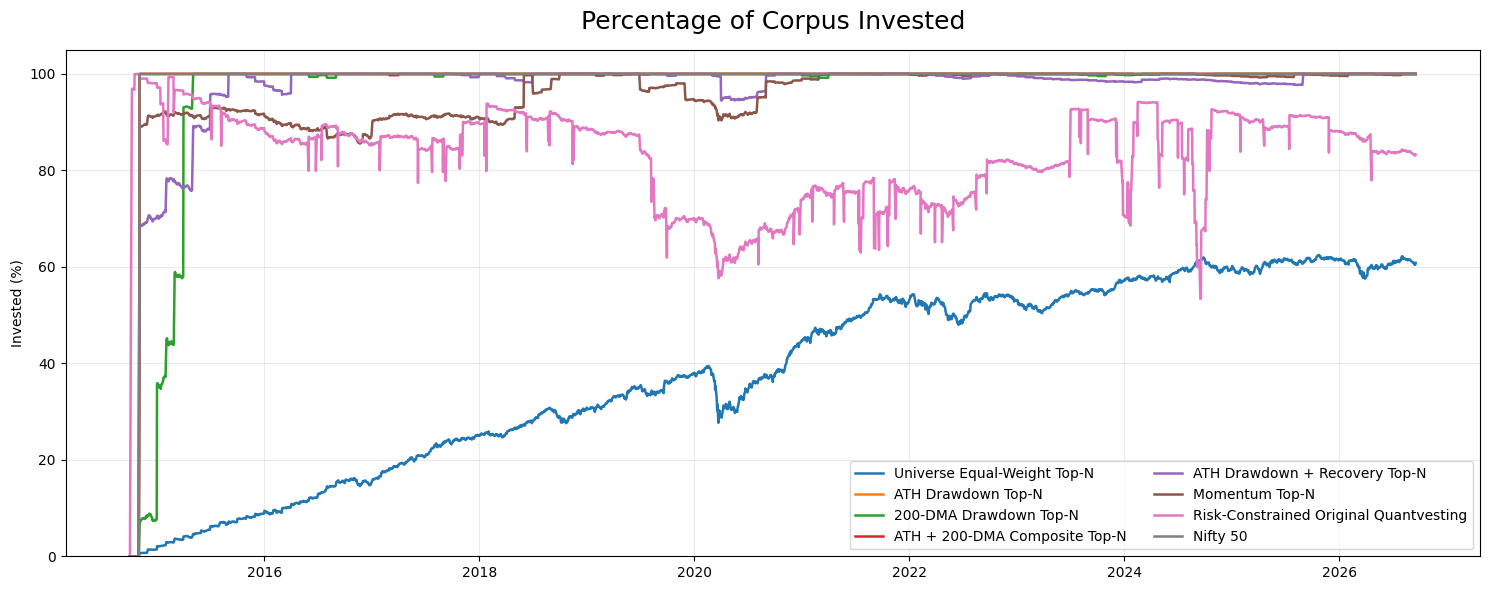

In [14]:
# 13. Invested percentage comparison
fig,ax=plt.subplots(figsize=(15,6))
for name,v in results.items():
    p=v["portfolio"].set_index("date")
    ax.plot(p.index,p["invested_pct"]*100,label=name,linewidth=1.8)
ax.set_title("Percentage of Corpus Invested",fontsize=18,pad=15)
ax.set_ylabel("Invested (%)"); ax.set_ylim(0,105); ax.grid(alpha=.25); ax.legend(ncol=2); plt.tight_layout(); plt.show()


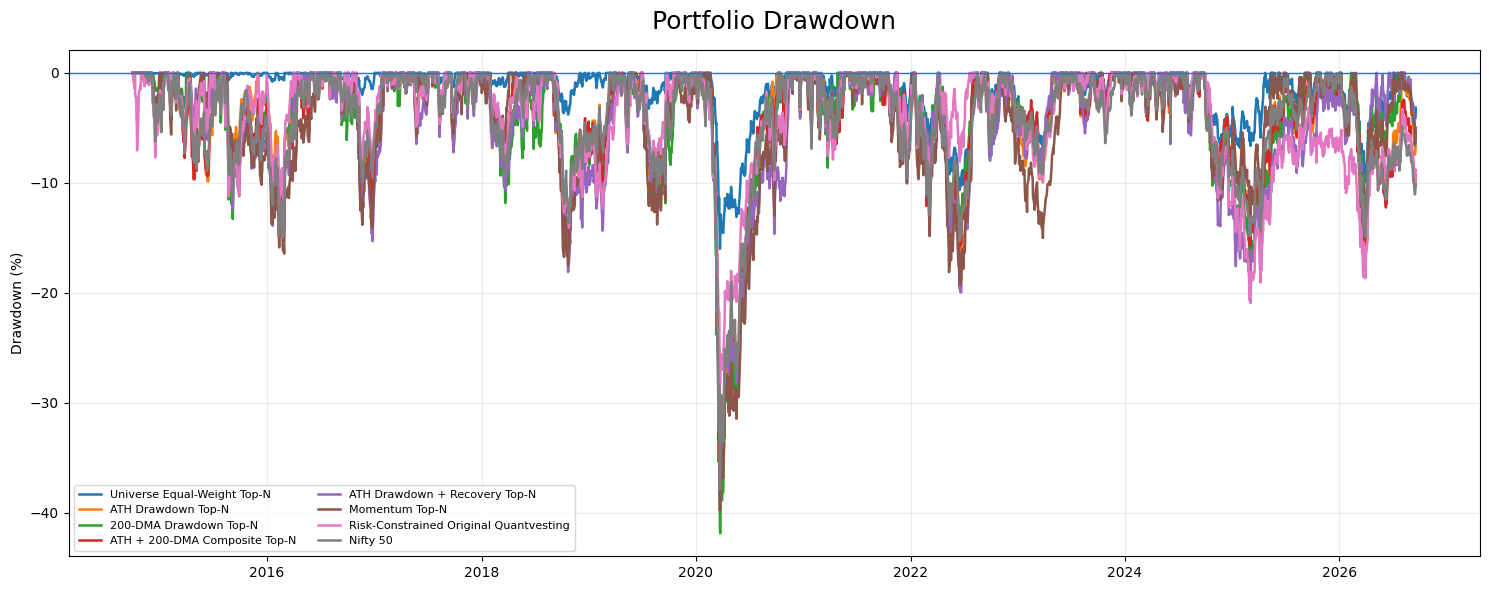

In [15]:
# 14. Drawdown comparison
fig,ax=plt.subplots(figsize=(15,6))
for name,v in results.items():
    p=v["portfolio"].set_index("date")
    ax.plot(p.index,p["drawdown"]*100,label=name,linewidth=1.8)
ax.axhline(0,linewidth=1)
ax.set_title("Portfolio Drawdown",fontsize=18,pad=15); ax.set_ylabel("Drawdown (%)"); ax.grid(alpha=.25); ax.legend(ncol=2,fontsize=8); plt.tight_layout(); plt.show()


In [16]:
# 15. Market-regime analysis
# Merge each strategy's daily portfolio with the Nifty diagnostic regime.
reg=regime_daily[["regime","drawdown","ret_6m"]].rename(columns={"drawdown":"nifty_drawdown","ret_6m":"nifty_6m_return"})
regime_tables={}
for name,v in results.items():
    p=v["portfolio"].copy().set_index("date")
    q=p.join(reg,how="inner")
    # Daily returns are used only for descriptive regime statistics.
    q["daily_return"]=q["portfolio_value"].pct_change()
    rows=[]
    for regime_name,g in q.groupby("regime"):
        if len(g)<5: continue
        start=float(g["portfolio_value"].iloc[0]); end=float(g["portfolio_value"].iloc[-1])
        rows.append({"Strategy":name,"Regime":regime_name,"Days":len(g),"Start Corpus":start,"End Corpus":end,
                     "Period Change":end/start-1 if start else np.nan,"Worst Drawdown":float(g["drawdown"].min()),
                     "Avg Invested %":float(g["invested_pct"].mean())})
    regime_tables[name]=pd.DataFrame(rows)

regime_summary=pd.concat(regime_tables.values(),ignore_index=True) if regime_tables else pd.DataFrame()
display(regime_summary.sort_values(["Regime","Strategy"]).style.format({"Start Corpus":"₹{:,.0f}","End Corpus":"₹{:,.0f}","Period Change":"{:.2%}","Worst Drawdown":"{:.2%}","Avg Invested %":"{:.1%}"}))

print("Regime definition used for diagnostics:")
print("• Stress / Bear: Nifty drawdown ≤ -10% and trailing 6-month return < 0")
print("• Recovery: Nifty drawdown ≤ -10% and trailing 6-month return ≥ 0")
print("• Expansion / Bull: drawdown > -7%, 6-month return > 0 and Nifty above 200-DMA")
print("• Transition / Sideways: remaining observations with sufficient history")


,Strategy,Regime,Days,Start Corpus,End Corpus,Period Change,Worst Drawdown,Avg Invested %
10,200-DMA Drawdown Top-N,Expansion / Bull,1082,"₹14,566,883","₹115,885,340",695.54%,-6.69%,99.9%
15,ATH + 200-DMA Composite Top-N,Expansion / Bull,1082,"₹14,789,044","₹104,042,339",603.51%,-5.33%,100.0%
20,ATH Drawdown + Recovery Top-N,Expansion / Bull,1082,"₹15,319,537","₹112,466,119",634.14%,-6.47%,99.6%
5,ATH Drawdown Top-N,Expansion / Bull,1082,"₹15,053,778","₹119,343,486",692.78%,-6.13%,100.0%
25,Momentum Top-N,Expansion / Bull,1082,"₹17,357,389","₹123,821,096",613.36%,-6.58%,97.3%
35,Nifty 50,Expansion / Bull,1082,"₹12,595,515","₹57,588,965",357.22%,-2.91%,100.0%
30,Risk-Constrained Original Quantvesting,Expansion / Bull,1082,"₹16,371,099","₹84,474,712",416.00%,-8.64%,82.8%
0,Universe Equal-Weight Top-N,Expansion / Bull,1082,"₹12,533,041","₹40,404,798",222.39%,-2.36%,43.4%
11,200-DMA Drawdown Top-N,Insufficient history,199,"₹10,000,000","₹11,127,945",11.28%,-6.22%,56.2%
16,ATH + 200-DMA Composite Top-N,Insufficient history,199,"₹10,000,000","₹11,778,425",17.78%,-9.69%,91.5%


Regime definition used for diagnostics:
• Stress / Bear: Nifty drawdown ≤ -10% and trailing 6-month return < 0
• Recovery: Nifty drawdown ≤ -10% and trailing 6-month return ≥ 0
• Expansion / Bull: drawdown > -7%, 6-month return > 0 and Nifty above 200-DMA
• Transition / Sideways: remaining observations with sufficient history


In [17]:
# 16. Calendar-year comparison — useful cross-check against regime labels
calendar_rows=[]
for name,v in results.items():
    p=v["portfolio"].copy(); p["year"]=p["date"].dt.year
    for year,g in p.groupby("year"):
        if len(g)<20: continue
        start=float(g["portfolio_value"].iloc[0]); end=float(g["portfolio_value"].iloc[-1])
        calendar_rows.append({"Strategy":name,"Year":year,"Start Corpus":start,"End Corpus":end,"Year Change":end/start-1 if start else np.nan,"Worst DD":float(g["drawdown"].min())})
calendar_df=pd.DataFrame(calendar_rows)
display(calendar_df.sort_values(["Year","Strategy"]).style.format({"Start Corpus":"₹{:,.0f}","End Corpus":"₹{:,.0f}","Year Change":"{:.2%}","Worst DD":"{:.2%}"}))


,Strategy,Year,Start Corpus,End Corpus,Year Change,Worst DD
26,200-DMA Drawdown Top-N,2014,"₹10,000,000","₹10,275,227",2.75%,-1.64%
39,ATH + 200-DMA Composite Top-N,2014,"₹10,000,000","₹10,400,865",4.01%,-5.86%
52,ATH Drawdown + Recovery Top-N,2014,"₹10,000,000","₹10,323,376",3.23%,-4.27%
13,ATH Drawdown Top-N,2014,"₹10,000,000","₹10,402,751",4.03%,-5.54%
65,Momentum Top-N,2014,"₹10,000,000","₹11,102,262",11.02%,-5.40%
91,Nifty 50,2014,"₹10,000,000","₹10,101,911",1.02%,-6.24%
78,Risk-Constrained Original Quantvesting,2014,"₹10,000,000","₹10,608,214",6.08%,-7.69%
0,Universe Equal-Weight Top-N,2014,"₹10,000,000","₹10,206,199",2.06%,-0.07%
27,200-DMA Drawdown Top-N,2015,"₹10,405,758","₹11,361,024",9.18%,-13.28%
40,ATH + 200-DMA Composite Top-N,2015,"₹10,481,142","₹11,912,925",13.66%,-10.29%


In [18]:
# 17. Monthly SIP diagnostics and concentration snapshots
monthly=pd.DataFrame({"date":sip_dates})
monthly["contribution"]=MONTHLY_SIP
for name,v in results.items():
    p=v["portfolio"].set_index("date")
    monthly[name+" Corpus"]=monthly["date"].map(lambda d: float(p.loc[d,"portfolio_value"]) if d in p.index else np.nan)
    monthly[name+" Cash"]=monthly["date"].map(lambda d: float(p.loc[d,"cash"]) if d in p.index else np.nan)
    monthly[name+" Invested %"]=monthly["date"].map(lambda d: float(p.loc[d,"invested_pct"]) if d in p.index else np.nan)

display(monthly.tail(12).style.format({c:"₹{:,.0f}" for c in monthly.columns if "Corpus" in c or c=="contribution" or "Cash" in c}).format({c:"{:.1%}" for c in monthly.columns if "Invested %" in c}).hide(axis="index"))


date,contribution,Universe Equal-Weight Top-N Corpus,Universe Equal-Weight Top-N Cash,Universe Equal-Weight Top-N Invested %,ATH Drawdown Top-N Corpus,ATH Drawdown Top-N Cash,ATH Drawdown Top-N Invested %,200-DMA Drawdown Top-N Corpus,200-DMA Drawdown Top-N Cash,200-DMA Drawdown Top-N Invested %,ATH + 200-DMA Composite Top-N Corpus,ATH + 200-DMA Composite Top-N Cash,ATH + 200-DMA Composite Top-N Invested %,ATH Drawdown + Recovery Top-N Corpus,ATH Drawdown + Recovery Top-N Cash,ATH Drawdown + Recovery Top-N Invested %,Momentum Top-N Corpus,Momentum Top-N Cash,Momentum Top-N Invested %,Risk-Constrained Original Quantvesting Corpus,Risk-Constrained Original Quantvesting Cash,Risk-Constrained Original Quantvesting Invested %,Nifty 50 Corpus,Nifty 50 Cash,Nifty 50 Invested %
2025-10-01 00:00:00,100000,39301566.537253,15308650.478537,61.0%,114283053.676549,485.609258,100.0%,106823139.321258,298.163604,100.0%,99823053.628748,471.775172,100.0%,106933484.433150,101269.404158,99.9%,114447803.053336,200647.121329,99.8%,86166828.917278,7704839.806316,91.1%,55239969.666067,0.000000,100.0%
2025-11-03 00:00:00,100000,40161235.202515,15366902.429200,61.7%,120517102.234106,539.968664,100.0%,112528957.539392,952.318506,100.0%,104899313.948970,526.134578,100.0%,112744285.903626,1273.764222,100.0%,118975415.155265,300647.121329,99.7%,86268655.142803,7804839.806316,91.0%,57401985.509892,-0.000000,100.0%
2025-12-01 00:00:00,100000,40489549.265946,15423942.664506,61.9%,120453987.434038,30.282915,100.0%,113436765.137157,190.552257,100.0%,104955171.726002,634.975391,100.0%,112460792.526226,1377.096783,100.0%,121824059.485343,400647.121329,99.7%,87273726.834764,10217891.529985,88.3%,58420114.523145,-0.000000,100.0%
2026-01-01 00:00:00,100000,40181699.901378,15480889.760143,61.5%,120542754.059710,215.735583,100.0%,113877914.596604,372.199052,100.0%,104375952.281995,396.793347,100.0%,112753536.825834,1294.751737,100.0%,122218336.135733,500647.121329,99.6%,86387079.897356,10317891.529985,88.1%,58454694.631370,-0.000000,100.0%
2026-02-02 00:00:00,100000,39311488.790098,15538606.709409,60.5%,115773544.304317,113.403133,100.0%,110060040.023157,269.866602,100.0%,100359079.914938,294.460897,100.0%,108644491.698096,2326.472327,100.0%,116890891.147685,1216.022563,100.0%,82758070.187670,10417891.529985,87.4%,56190059.895978,-0.000000,100.0%
2026-03-02 00:00:00,100000,39690038.672553,15596633.523016,60.7%,115823898.006101,239.767271,100.0%,113269096.169024,37.693561,100.0%,100349703.890975,62.287856,100.0%,110161765.696474,2897.502687,100.0%,120061333.072989,1121.757925,100.0%,81951745.555193,10517891.529985,87.2%,55791966.030851,-0.000000,100.0%
2026-04-01 00:00:00,100000,37159916.847158,15654564.994253,57.9%,105651765.070843,207.894330,100.0%,103200334.670728,19.841627,100.0%,90679843.788767,44.435922,100.0%,100581910.005159,840.595735,100.0%,108046820.118510,1096.895488,100.0%,76810408.200395,10617891.529985,86.2%,50985389.920947,-0.000000,100.0%
2026-05-01 00:00:00,100000,38886490.932553,15710964.870114,59.6%,112674486.006610,157.297260,100.0%,111259267.482519,46.758703,100.0%,97442654.335422,54.427738,100.0%,112952983.721865,1678.827700,100.0%,115747363.103496,101096.895488,99.9%,84212375.537869,13636104.841549,83.8%,nan,nan,nan%
2026-06-01 00:00:00,100000,39213888.085520,15770824.429697,59.8%,109682336.660013,68.539164,100.0%,109557183.186677,30.313112,100.0%,94386303.902023,253.901473,100.0%,113426447.473860,420.914228,100.0%,115124713.378276,201096.895488,99.8%,84493468.265942,13736104.841549,83.7%,52664949.241761,-0.000000,100.0%
2026-07-01 00:00:00,100000,40219386.494152,15831050.538463,60.6%,112740611.973345,69.964922,100.0%,111569699.181294,284.767049,100.0%,97167455.572775,148.817648,100.0%,116524823.848323,2297.901240,100.0%,120933906.742900,301096.895488,99.8%,84738236.349163,13836104.841549,83.7%,54169006.007324,0.000000,100.0%


In [19]:
# 18. Concentration analysis from trade ledgers
# This is based on marked-to-market positions reconstructed from executed buys.
def concentration_snapshot(trades, portfolio, name):
    if trades.empty or "symbol" not in trades.columns:
        return pd.DataFrame()
    buys=trades[trades["event"].astype(str).str.contains("BUY|ENTRY",regex=True)].copy()
    if buys.empty:return pd.DataFrame()
    # Approximate cumulative invested cost by symbol; useful as a contribution/concentration diagnostic.
    by=buys.groupby("symbol")["notional"].sum().sort_values(ascending=False)
    total=by.sum()
    top5=by.head(5).sum()/total if total else np.nan
    top10=by.head(10).sum()/total if total else np.nan
    return pd.DataFrame([{"Strategy":name,"Top-5 share of cumulative purchases":top5,"Top-10 share of cumulative purchases":top10,"Distinct purchased stocks":by.size}])

conc=pd.concat([concentration_snapshot(v["trades"],v["portfolio"],name) for name,v in results.items() if name!="Nifty 50"],ignore_index=True)
display(conc.style.format({"Top-5 share of cumulative purchases":"{:.1%}","Top-10 share of cumulative purchases":"{:.1%}"}))


,Strategy,Top-5 share of cumulative purchases,Top-10 share of cumulative purchases,Distinct purchased stocks
0,Universe Equal-Weight Top-N,39.7%,76.3%,15
1,ATH Drawdown Top-N,59.9%,85.2%,15
2,200-DMA Drawdown Top-N,52.1%,82.3%,15
3,ATH + 200-DMA Composite Top-N,51.4%,82.7%,15
4,ATH Drawdown + Recovery Top-N,54.7%,83.5%,15
5,Momentum Top-N,59.6%,89.7%,15
6,Risk-Constrained Original Quantvesting,25.9%,43.7%,47


## 4. Audit and implementation checks

The audit is designed to answer one question: **did every equity strategy actually use the same portfolio implementation constraints?**

Checks include:

- 60 monthly contributions;
- total contributed capital is ₹1.50 Cr;
- all equity BUY quantities are integers;
- all equity TRIM/EXIT quantities are integers;
- no negative shares;
- maximum 15 open holdings;
- every BUY respects the 7% position cap at execution;
- every BUY respects the 20% sector cap at execution;
- hard concentration breaches are followed by TRIM events where execution data permits;
- cash never becomes negative;
- cash + marked-to-market invested value equals portfolio corpus;
- no routine sells occur in the six primary no-sell strategies;
- the risk-constrained original reference respects the same common controls;
- the Nifty 50 benchmark is treated separately because it is an index rather than a basket of separately traded scrips.


In [20]:
# 19. Backtest audit
audit = []

equity_strategies = PRIMARY_STRATEGIES + ["Risk-Constrained Original Quantvesting"]

for name in equity_strategies:
    v = results[name]
    p = v["portfolio"]
    t = v["trades"]

    buys = t[t["event"].astype(str).str.contains("BUY|ENTRY", regex=True)].copy() if not t.empty else pd.DataFrame()
    trims = t[t["event"] == "TRIM"].copy() if not t.empty else pd.DataFrame()
    exits = t[t["event"] == "EXIT"].copy() if not t.empty else pd.DataFrame()

    integer_buy_ok = bool(np.all(np.isclose(buys["shares"], np.round(buys["shares"])))) if not buys.empty else True
    all_sales = pd.concat([trims["shares"], exits["shares"]], ignore_index=True) if (not trims.empty or not exits.empty) else pd.Series(dtype=float)
    integer_sell_ok = bool(np.all(np.isclose(all_sales, np.round(all_sales)))) if len(all_sales) else True

    position_ok = bool((buys["position_pct_after"] <= MAX_POSITION_PCT + 1e-10).all()) if not buys.empty else True
    sector_ok = bool((buys["sector_pct_after"] <= MAX_SECTOR_PCT + 1e-10).all()) if not buys.empty else True
    holding_ok = bool((p["open_positions"] <= MAX_HOLDINGS).all())

    audit.append({
        "Strategy": name,
        "Journey months": len(sip_dates_all) == (EXPECTED_MONTHS if EXPECTED_MONTHS is not None else len(sip_dates_all)),
        "Configured capital": abs(v["contributions"]["contribution"].sum() - (INITIAL_LUMP_SUM + MONTHLY_SIP * len(sip_dates))) < 1e-6,
        "Integer BUY shares": integer_buy_ok,
        "Integer SELL/TRIM shares": integer_sell_ok,
        "7% position cap": position_ok,
        "20% sector cap": sector_ok,
        "≤15 holdings": holding_ok,
        "Cash non-negative": bool((p["cash"] >= -1e-7).all()),
        "Accounting identity": bool(np.allclose(
            p["cash"] + p["invested_value"], p["portfolio_value"], rtol=0, atol=1e-6
        )),
        "Trim events": int(len(trims)),
        "Frozen-ATH exits": int(len(exits)),
    })

audit_df = pd.DataFrame(audit)
display(audit_df.style.hide(axis="index"))

print("\nBenchmark note: Nifty 50 is an index reference, so stock-level 7% and 20% sector constraints are not applied to it.")


Strategy,Journey months,Configured capital,Integer BUY shares,Integer SELL/TRIM shares,7% position cap,20% sector cap,≤15 holdings,Cash non-negative,Accounting identity,Trim events,Frozen-ATH exits
Universe Equal-Weight Top-N,False,True,True,True,True,True,True,True,True,0,0
ATH Drawdown Top-N,False,True,True,True,True,True,True,True,True,4,0
200-DMA Drawdown Top-N,False,True,True,True,True,True,True,True,True,2,0
ATH + 200-DMA Composite Top-N,False,True,True,True,True,True,True,True,True,4,0
ATH Drawdown + Recovery Top-N,False,True,True,True,True,True,True,True,True,4,0
Momentum Top-N,False,True,True,True,True,True,True,True,True,4,0
Risk-Constrained Original Quantvesting,False,True,True,True,True,True,True,True,True,2,76



Benchmark note: Nifty 50 is an index reference, so stock-level 7% and 20% sector constraints are not applied to it.


In [21]:
# 20. Final dashboard — descriptive comparison, not a single-score ranking
headline = metrics[[
    "Contributed Capital", "Ending Corpus", "Profit", "XIRR", "Max Drawdown",
    "Average Invested %", "Average Cash %", "Final Cash",
    "Deployment %", "Final Holdings", "Buy Events", "Trim Events", "Exit Events"
]].copy()
headline["Profit % of Contributions"] = headline["Profit"] / headline["Contributed Capital"]

display(headline.sort_values("Ending Corpus", ascending=False).style.format({
    "Ending Corpus": "₹{:,.0f}", "Profit": "₹{:,.0f}", "XIRR": "{:.2%}",
    "Max Drawdown": "{:.2%}", "Average Invested %": "{:.1%}",
    "Average Cash %": "{:.1%}", "Final Cash": "₹{:,.0f}",
    "Deployment %": "{:.1f}%", "Profit % of Contributions": "{:.1%}",
    "Final Holdings": "{:,.0f}", "Buy Events": "{:,.0f}",
    "Trim Events": "{:,.0f}", "Exit Events": "{:,.0f}"
}))

print("\nCommon equity constraints:")
print(f"  • {MAX_HOLDINGS} maximum holdings")
print(f"  • {TOP_N} candidates per monthly screen; {MAX_HOLDINGS} maximum open holdings")
print(f"  • {MAX_POSITION_PCT:.0%} maximum position at purchase")
print(f"  • {MAX_SECTOR_PCT:.0%} maximum sector exposure at purchase")
print("  • Integer shares only")
print(f"  • >{POSITION_HARD_PCT:.0%} position -> next-month trim toward {POSITION_TRIM_TARGET_PCT:.0%}")
print("  • Sector overages caused by appreciation are not forcibly sold")
print("  • Primary signal strategies otherwise have no routine sell signal")

print("\nHistorical comparison only: this notebook describes what the rules would have produced under the stated assumptions. It is not a forecast or investment recommendation.")

,Contributed Capital,Ending Corpus,Profit,XIRR,Max Drawdown,Average Invested %,Average Cash %,Final Cash,Deployment %,Final Holdings,Buy Events,Trim Events,Exit Events,Profit % of Contributions
Momentum Top-N,24300000.000000,"₹123,241,321","₹98,941,321",18.56%,-39.76%,95.8%,4.2%,₹110,116.2%,15,157,4,0,407.2%
ATH Drawdown + Recovery Top-N,24300000.000000,"₹119,227,217","₹94,927,217",18.18%,-39.09%,97.4%,2.6%,₹204,114.1%,15,162,4,0,390.6%
ATH Drawdown Top-N,24300000.000000,"₹114,712,400","₹90,412,400",17.74%,-39.79%,99.4%,0.6%,₹146,128.1%,15,290,4,0,372.1%
200-DMA Drawdown Top-N,24300000.000000,"₹113,990,209","₹89,690,209",17.67%,-41.85%,96.9%,3.1%,₹227,112.6%,15,227,2,0,369.1%
ATH + 200-DMA Composite Top-N,24300000.000000,"₹96,138,627","₹71,838,627",15.74%,-37.47%,99.4%,0.6%,₹114,128.2%,15,301,4,0,295.6%
Risk-Constrained Original Quantvesting,24300000.000000,"₹83,931,379","₹59,631,379",14.20%,-28.29%,83.6%,16.4%,"₹14,036,105",1057.8%,15,91,2,76,245.4%
Nifty 50,23800000.000000,"₹52,872,649","₹29,072,649",8.97%,-37.85%,99.4%,0.6%,₹0,99.9%,1,138,0,0,122.2%
Universe Equal-Weight Top-N,24300000.000000,"₹40,737,680","₹16,437,680",6.00%,-15.99%,38.3%,61.7%,"₹15,952,364",34.3%,15,"1,921",0,0,67.6%



Common equity constraints:
  • 15 maximum holdings
  • 20 candidates per monthly screen; 15 maximum open holdings
  • 7% maximum position at purchase
  • 20% maximum sector exposure at purchase
  • Integer shares only
  • >15% position -> next-month trim toward 12%
  • Sector overages caused by appreciation are not forcibly sold
  • Primary signal strategies otherwise have no routine sell signal

Historical comparison only: this notebook describes what the rules would have produced under the stated assumptions. It is not a forecast or investment recommendation.
